## Introduction

<div style="text-align: justify"> 
What makes a tournament experience successful? There are many aspects to these questions: the venue, the organisation, the tables, food etc. 
I would like to tackle the question from the perspective of the actual games. As a Tournament Organiser (TO), what should you prioritise when designing a pairing and scoring system? Do you want a system that maximises the chances that the best player wins the event? Or would you rather have a system that keeps games as balanced and enjoyable as possible for players of all skill levels? And for that matter, what does it even mean to be "the best player"?

In this article, I try to define and quantify a number of tournament criteria. I then compare two scoring systems, Northern Kings and Black Jack, to see how they perform against these criteria. I also study how small variations of these systems  can affect the overall tournament experience.

The goal is not to find the one perfect scoring system. Different tournaments have different objectives. Instead, the aim is to provide TOs with some data and insights that can help them choose the system that best matches the type of event they want to run.

To do this, I use Monte Carlo simulations—which is a fancy way of saying that I let a computer play out thousands of tournaments and record the results. This is equivalent to throwing a lot of dice, which seems appropriate for evaluating a kings of war pairing system!

The results suggest that, for the criteria considered here, there is little reason to use the Black Jack system, as it tends to perform worse in most situations. The Northern Kings system appears fairly robust, although no scoring system proves capable of consistently identifying and ranking the strongest players perfectly. </div>

## Plan

This article is organised as follows:

* **Simulation design:** how the tournament simulator works and the assumptions used in the model.
* **Scoring systems:** a summary of the Northern Kings and Black Jack systems, together with the variations considered in this study.
* **Evaluation criteria:** the metrics used to assess and compare scoring systems.
* **Results:** a comparison of the different scoring systems against the selected criteria.
* **Discussion:** an interpretation of the results, the conclusions that can be drawn from them, and the limitations of the study.


## I. Simulation design 

TODO INTRO

### Generating player profiles

<div style="text-align: justify"> 
To simulate our tournament, let us first generate "player profiles". I use the ELO system to determine the relative probability of each player winning a game. I use the common chess interpretation for this (although assuming a smaller gap between the very best players and the average ones). Thus, an ELO of 1000 is used for a beginner, an average player has an ELO around 1200–1400, your local club champion is around 1800–2000, and I arbitrarily assume our national masters are around 2200. Clearly, as with all arbitrary decisions in this discussion, this could be subject to debate, but hopefully we observe similar patterns when varying these parameters.

For now, I consider a 32-player tournament, which nicely converges to a maximum of one player with five wins if winners only play against winners, in which case ideally this player should be the winner (we will see that unfortunately this is not always the case).

Later on, I consider larger tournaments to cover cases such as the Clash of Kings tournament, which gathers about 200 players.

Later, we also study how a different ELO distribution can affect the outcomes of our study.</div> 

In [41]:
N_PLAYERS = 32
MIN_ELO = 1300
MAX_ELO = 1900
AVG_ELO = 1400
NUM_ROUNDS = 5 if N_PLAYERS <= 32 else 6  # 5 rounds for up to 32 players, 6 for larger fields

### Probability of Winning Based on ELO Ratings

What does it mean to have a certain ELO rating? 
For two players, Player A and Player B, with ELO ratings $( R_A )$ and $( R_B )$ respectively, the expected score (probability of winning) for player A can be calculated using the following formulas:

$$ E_A = \frac{1}{1 + 10^{(R_B - R_A) / 400}} $$

So what are the chances of a  local club champion to beat a national master?
let's see:

In [42]:
def win_probability(rating_a, rating_b):
    """
    Compute the probability of Player A winning against Player B based on their Elo ratings.
    
    Parameters:
    rating_a (float): Elo rating of Player A.
    rating_b (float): Elo rating of Player B.
    
    Returns:
    float: Probability of Player A winning.
    """
    prob_a = 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
    
    return prob_a


rating_a = 1750
rating_b = 2200

prob_a = win_probability(rating_a, rating_b)

print(f"Probability of Player A winning: {prob_a * 100.:.1f}%")
print(f"Probability of Player B winning: {100*(1.-prob_a):.1f}%")

Probability of Player A winning: 7.0%
Probability of Player B winning: 93.0%


What about a very good local club champion vs a top player ?

In [43]:
rating_a = 2000
rating_b = 2200

prob_a = win_probability(rating_a, rating_b)

print(f"Probability of Player A winning: {prob_a * 100.:.1f}%")
print(f"Probability of Player B winning: {100*(1.-prob_a):.1f}%")

Probability of Player A winning: 24.0%
Probability of Player B winning: 76.0%


Let us also check that two equivalent players have similar chances of winning

In [44]:
rating_a = 1300
rating_b = 1300

prob_a = win_probability(rating_a, rating_b)

print(f"Probability of Player A winning: {prob_a * 100.:.1f}%")
print(f"Probability of Player B winning: {100*(1.-prob_a):.1f}%")

Probability of Player A winning: 50.0%
Probability of Player B winning: 50.0%


### Generating 32 players

I will now generate player profiles, with a normal distribution centered around 1400 and plot the resulting ELOs to check that this is somewhat what we expect in terms of player distribution. To check that the distribution is what we expect I ll generate more than 32, say 10000 instead, otherwise the results will not be representative.

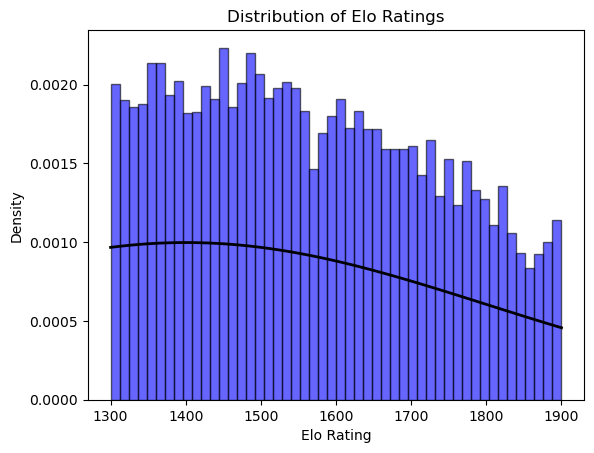

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import truncnorm

std_dev = 400
def generate_normal_elo_ratings(num_ratings=N_PLAYERS, mean=AVG_ELO, std_dev=std_dev, lower_bound=MIN_ELO, upper_bound=MAX_ELO):
    X = truncnorm((lower_bound - mean) / std_dev, (upper_bound - mean) / std_dev, loc=mean, scale=std_dev) 
    return X.rvs(num_ratings)

def plot_ratings(elo_ratings):# Plot the histogram of Elo ratings
    plt.hist(elo_ratings, bins=50, density=True, alpha=0.6, color='b', edgecolor='black')

    # Plot the normal distribution curve
    xmin, xmax = MIN_ELO, MAX_ELO
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, AVG_ELO, std_dev)
    plt.plot(x, p, 'k', linewidth=2)

    # Add titles and labels
    plt.title('Distribution of Elo Ratings')
    plt.xlabel('Elo Rating')
    plt.ylabel('Density')

    # Show the plot
    plt.show()

elo_ratings = generate_normal_elo_ratings(num_ratings=10000)
plot_ratings(elo_ratings)



Ok, it looks like our code runs correctly. In average our players have an ELO of 1400 and only a minority will be among the very top. To generate a set of player profiles I can now simply call:

In [46]:
player_profiles = generate_normal_elo_ratings()


Let's plot an example of player profiles for one tournament, sorted by their theoretical ELOs.

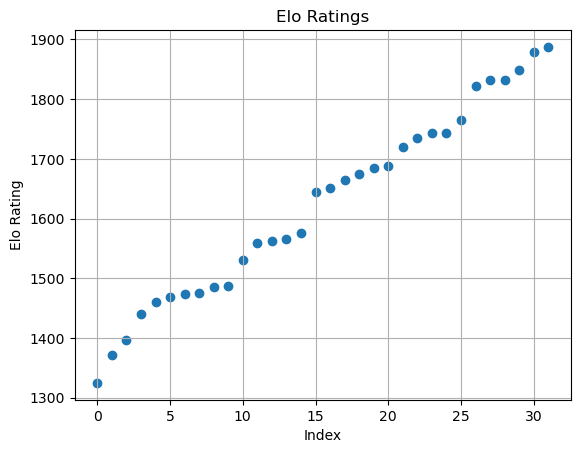

In [47]:
player_profiles = sorted(generate_normal_elo_ratings())
indices = list(range(len(player_profiles)))
plt.scatter(indices, player_profiles)
plt.title('Elo Ratings')
plt.xlabel('Index')
plt.ylabel('Elo Rating')
plt.grid(True)
plt.show()

In this event there are a few beginners, a good distribution of average players, few local champions and one contendent for the Uk masters! In our tests we will run several instances of tournaments under different systems to obtain a comparison of the outcomes as fair as possible

### Simulating a game.

To play a game, we already know the probability for a player A to win against player B, but this is insufficient to determine the outcome of a KOW game according to the main scoring systems. Indeed, we need to consider draws, Kill points and scenario points.

#### Win, Loss or draw ? 
The ELO system does not allow to predict draws directly. However, we can use an empirical distribution which, given the $E_A$ score, tells us the probability of winning / drawing or losing. I ll use the following table, arbitrarily assuming that 2 players with the same level will have 20% chances of drawing:

| E[score] | P(win) | P(draw) | P(lose) |
|----------|--------|---------|---------|
| 0.0      | 0.00   | 0.00    | 1.00    |
| 0.1      | 0.09   | 0.02    | 0.89    |
| 0.2      | 0.17   | 0.06    | 0.77    |
| 0.3      | 0.24   | 0.12    | 0.64    |
| 0.4      | 0.31   | 0.18    | 0.51    |
| 0.5      | 0.40   | 0.20    | 0.40    |
| 0.6      | 0.51   | 0.18    | 0.31    |
| 0.7      | 0.64   | 0.12    | 0.24    |
| 0.8      | 0.77   | 0.06    | 0.17    |
| 0.9      | 0.89   | 0.02    | 0.09    |
| 1.0      | 1.00   | 0.00    | 0.00    |

Using this table, we can "play" a game between two players and determine the outcome. I ll first interpolate the discrete values of the table to obtain a continuous definition of the probabilities:


In [48]:
Es = [(float(i) * 0.1) for i in range (11)]
def interpolate(data):
    coeffs = np.polyfit(Es, data, 4)
    poly_func = np.poly1d(coeffs)
    return poly_func


win_data  = [0. ,0.09,0.17,0.24,0.31,0.40,0.51,0.64,0.77,0.89,1.0]
draw_data = [0. ,0.02,0.06,0.12,0.18,0.20,0.18,0.12,0.06,0.02,0.0]
loss_data = win_data[:]; loss_data.reverse()
loss_data
p_win  = interpolate(win_data) 
p_draw = interpolate(draw_data) 
p_loss = interpolate(loss_data) 
   

Let's plot our functions to check we are all good:

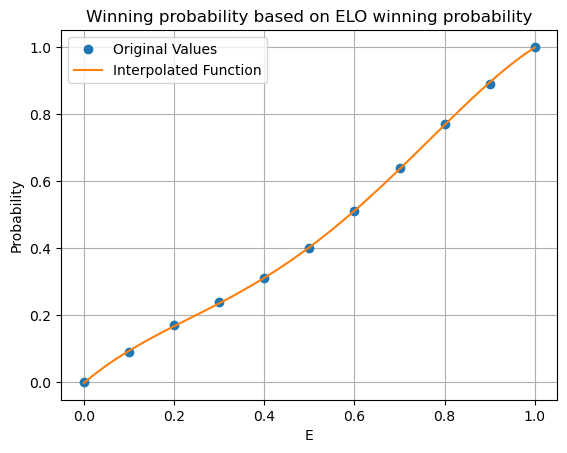

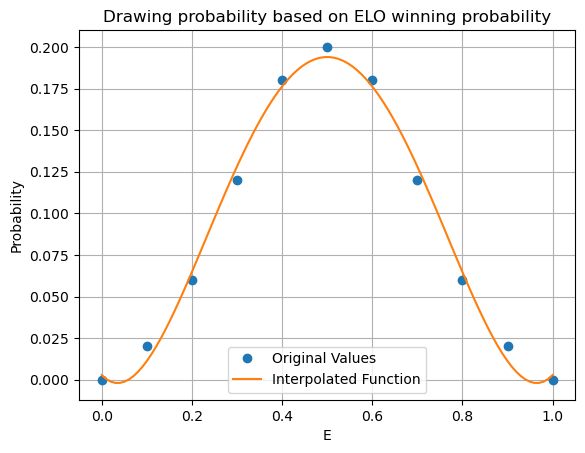

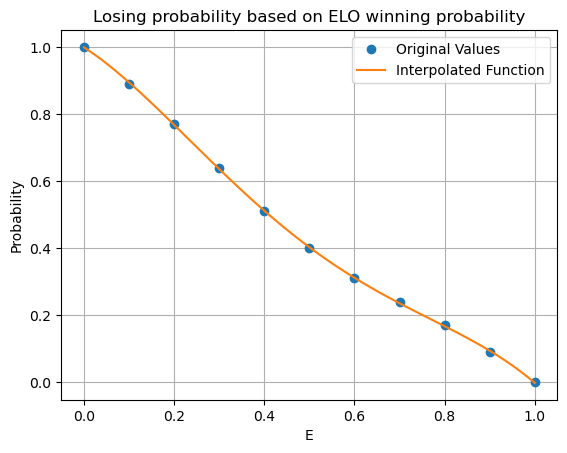

In [49]:
def plot_interpolation(x_values, y_values, interp_x_values, interp_y_values, title):
    """
    Plot the original values and the interpolated function.
    
    Parameters:
    x_values (list or array): List of original x values.
    y_values (list or array): List of original y values.
    interp_x_values (array): Interpolated x values.
    interp_y_values (array): Interpolated y values.
    """
    plt.plot(x_values, y_values, 'o', label='Original Values')
    plt.plot(interp_x_values, interp_y_values, '-', label='Interpolated Function')
    plt.xlabel('E')
    plt.ylabel('Probability')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
interp_x_values = np.linspace(min(Es), max(Es), 100)
interp_y_values = p_win(interp_x_values)
plot_interpolation(Es, win_data, interp_x_values, interp_y_values, "Winning probability based on ELO winning probability")

interp_x_values = np.linspace(min(Es), max(Es), 100)
interp_y_values = p_draw(interp_x_values)
plot_interpolation(Es, draw_data, interp_x_values, interp_y_values, "Drawing probability based on ELO winning probability")

interp_x_values = np.linspace(min(Es), max(Es), 100)
interp_y_values = p_loss(interp_x_values)
plot_interpolation(Es, loss_data, interp_x_values, interp_y_values, "Losing probability based on ELO winning probability")


I m allowing myself a few approximations here, because the sum of probabilities is only "roughly" equal to 1 (and also the drawing interpolation can give negative probabilities, but we will just assume they are 0 in the method proposed right after). While statisticians are probably dying at this point, I am pretty sure this is enough for our project, as long as the game resolution accounts for this. I will now write a function that given two ELO ratings, returns whether the outcome is a win, a draw or a loss for player A. For this I ll randomly generate a number between 0 and 1. If that number is lower or equal than the losing probability, then player A will have lost. If not and the number is lower or equal than the losing + drawing probability, then the result is a draw. Otherwise, player A will have won. 

We will return 1 for a loss, 2 for a draw, and 3 for a win

In [50]:
from numpy import random
def play_match(rating_a, rating_b):
    """
    Determine the outcome of a match between player A and B
    
    Parameters:
    rating_a (float): Elo rating of Player A.
    rating_b (float): Elo rating of Player B.
    
    Returns:
    int: 1, 2 or 3 respectively if player A lost, drew or won
    """
    prob_a = win_probability(rating_a, rating_b)
    roll = random.uniform(0, 1)
    if roll <= p_loss(prob_a):
        return 1
    elif roll <= p_loss(prob_a) + p_draw(prob_a):
        return 2
    else:
        return 3
    
    


As always let's check that the outcome is what we expect somehow

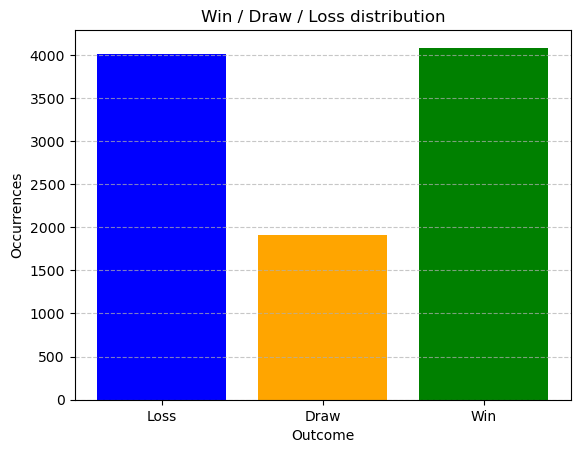

In [51]:
int_list = [play_match(1500, 1500) for _ in range (10000)]
occurrences = [int_list.count(1), int_list.count(2), int_list.count(3)]
    
# Integer labels
integers = ["Loss", "Draw", "Win"]
    
# Plotting
plt.bar(integers, occurrences, color=['blue', 'orange', 'green'])
plt.xlabel('Outcome')
plt.ylabel('Occurrences')
plt.title('Win / Draw / Loss distribution')
plt.xticks(integers)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### How big is a win / loss ?
Depending on the scoring system, a big win or loss has a different meaning in terms of KP / VP etc. So for now, we will simply attribute a score between 0 and 1 that says how "good" was the win/ the draw / the loss. A score of 1 means that the player should score the maximum number of points while a score or 0 means that the victory is the minimum possible. In the outcome, there will be one such number per player as for instance in the Northern Kings scoring system you can lose but kill most of the opponent army. These two numbers will later be interpreted by the scoring system to output a viable outcome.

I chose to link the probability of a "big" win to the actual probability of winning, by centering the distribution of the sample around it. For instance if you have a probability of winning of 80% the winning score is likely to be around 0.8, although a score of 0 remains possible but less likely. Let us reimplement the ```play_match``` function accordingly. Instead of outputting only a result, it also outputs 2 additional numbers who represents the score of each player

In [52]:
from numpy import random

def biased_draw(mean, std_dev = 0.1):
    # Rejection sampling: much faster than creating a truncnorm object each time
    while True:
        x = np.random.normal(mean, std_dev)
        if 0.0 <= x <= 1.0:
            return x


def play_match(rating_a, rating_b):
    """
    Determine the outcome of a match between player A and B
    
    Parameters:
    rating_a (float): Elo rating of Player A.
    rating_b (float): Elo rating of Player B.
    
    Returns:
    a triplet:
        int: 1, 2 or 3 respectively if player A lost, drew or won
        float: a [0,1] float indicative of how many points should the player A receive 
        float: a [0,1] float indicative of how many points should the player B receive 
    """
    prob_a = win_probability(rating_a, rating_b)
    roll = random.uniform(0, 1)
    outcome_number = -1 
    outcome_rate_a = -1.;
    outcome_rate_b = -1.;
    if roll <= p_loss(prob_a):
        outcome_number = 1 #loss        
    elif roll <= p_loss(prob_a) + p_draw(prob_a):
        outcome_number = 2 #draw
    else:
        outcome_number = 3 #win
    outcome_rate_a = biased_draw(p_win(prob_a));
    outcome_rate_b = biased_draw(p_win(1.-prob_a));
    return [outcome_number, outcome_rate_a, outcome_rate_b]
    

Let's just check that this works. Let's have two players with a ELO rating difference of about 240, such that  player A has about 77% chances of winning. Let's have them play N times and check that:
+ overall player A wins 77% of the time
+ Whether he wins, draws or loses, the score is centered around 0.77 
+ Player B's score is centered around 0.17

In [ ]:
N = 10000
# 1710 vs 1500 gives win_probability ≈ 0.770
ra, rb = 1710, 1500
print(f"win_probability(A) = {win_probability(ra, rb):.3f}")

results = [play_match(ra, rb) for _ in range(N)]
wins  = [r for r in results if r[0] == 3]
draws = [r for r in results if r[0] == 2]
losses= [r for r in results if r[0] == 1]

print(f"Win rate  : {len(wins)/N*100:.1f}%  (expected ~77%)")
print(f"Draw rate : {len(draws)/N*100:.1f}%")
print(f"Loss rate : {len(losses)/N*100:.1f}%")

# Score distributions
import numpy as np
import matplotlib.pyplot as plt

scores_a = [r[1] for r in results]
scores_b = [r[2] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(scores_a, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(np.mean(scores_a), color='red', linestyle='--',
                label=f'mean = {np.mean(scores_a):.2f}  (expected ≈ 0.77)')
axes[0].set_title('Player A score distribution')
axes[0].set_xlabel('score'); axes[0].legend()

axes[1].hist(scores_b, bins=30, color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(np.mean(scores_b), color='blue', linestyle='--',
                label=f'mean = {np.mean(scores_b):.2f}  (expected ≈ 0.17)')
axes[1].set_title('Player B score distribution')
axes[1].set_xlabel('score'); axes[1].legend()

plt.suptitle(f'play_match check — {N} games, ELO {ra} vs {rb}')
plt.tight_layout()
plt.show()


After all this we now have a single function ```play_match``` that simulates a match between two players based on their ELO score.


## Playing a KOW tournament
We now have a mean of determining who wins. However there are other things that we need to consider if we want to compare scoring systems.

First, we need to compare the systems based on the same outcome for all  possible encounters (which is a problem because the matches played will not be the same depending on the systems).


Secondly, victory / loss / draw is not sufficient as we also need the kill points and the scenario points in most scoring systems. Other criteria might be considered but they are not relevant here in general.

### Generating encounters data
Depending on the system implemented, given the same outcomes different players will play against each other in a tournament. When comparing the system, to make sure that the same outcome is considered we will first simulate all the games possible (ie each player will play each other player). We will actually do this 5 times just to make sure that in the case players play several times against each other we also have these outcomes. (NB: the number of times players encounter each other is also a criteria for evaluating a scoring system). Given all the possible encounters outcome, we will then be able to apply each scoring system to the same data and evaluate the outcome of the tournament.

From now on, each player is identified by its index in the ELO ratings list, between 0 and 31


In [53]:
#we will store all the data into a list of list

def play(elo, opponents):
    return [[play_match(elo, elo_opponent) for _ in range(5)] for elo_opponent in opponents]

def tournament_data(elo_ratings):
    return [play(elo_ratings[i],elo_ratings[i+1:]) for i in range(len(elo_ratings)-1)]
    

#Uncomment the following lines to generate the tournament data. Note that it will take a while to run, as it simulates 5 matches for each pair of players in a 32 player tournament.

#elo_ratings = generate_normal_elo_ratings(N_PLAYERS)
#tournament_matches = tournament_data(elo_ratings)



To retrieve the outcome of a specific match we can write the following function. The ```remove_encounter``` parameter is used to remove the instance of the match and return a new outcome if players are to meet again.


In [54]:
def rev(num):
    if num == 1:
        return 3
    elif num == 3:
        return 1
    return 2

#return outcomes from player A perspective
def match_result(tournament_matches, playerAIndex, playerBIndex, remove_encounter=False):
    minIdx = min(playerAIndex, playerBIndex);
    maxIdx = max(playerAIndex, playerBIndex);
    outcome = tournament_matches[minIdx][maxIdx-1-minIdx][0]
    if playerAIndex > playerBIndex: #reverse outcomes
        outcome =[rev(outcome[0]),outcome[2], outcome[1]]
    if remove_encounter:
        tournament_matches[minIdx][maxIdx-1-minIdx][:] = tournament_matches[minIdx][maxIdx-1-minIdx][1:]
    return outcome        


## "Unrolling" a tournament
A tournament consists in the following steps:

1. randomly assign opponents
2. play all the games for the current round
3. rank the players according to their current score
4. If all the games have been played, go back to step 2. If not, the rank obtained is the final ranking

In our case, step 1 is already solved. Since we randomly assign profiles to the player, we can simply assign matches by progressing towards the list of profiles. We will need to add more information on the player profile though: an Id and a current score. We will also add a history of their encounters as an helper.




In [55]:
class Player:
    def __init__(self, idx, elo):
        self.idx = idx
        self.elo = elo
        self.score = 0
        self.resulttrack = []
        self.opponenttrack = []
        self.track = []
    def __str__(self):
        return f"Player {self.idx}: Elo={self.elo}, Score={self.score}\n\t, Track{self.track}"
    def __repr__(self):
        return f"Player {self.idx}: Elo={self.elo}, Score={self.score}\n\t, Track{self.track}"

Step 2 is just a matter of retrieving the outcomes which we computed before.

Step 3 is the **ranking step** — how players are sorted between rounds determines who plays whom next, and the final ranking. We implement several ranking strategies:

- **`score`**: pure cumulative score (SP + KP), used by Northern Kings and Black Jack
- **`naive`**: wins → draws → score (simple win-count priority)
- **`wdl_sos`**: wins → draws → **Strength of Schedule** → score — a tiebreaker borrowed from chess
- **`wt_flat_sos`**: wins → draws → flat weighted wins → SOS → score

### Strength of Schedule (SOS)

The **Strength of Schedule** (also known as the *Buchholz score* in chess) is defined after round $r$ as:

$$SOS_i^{(r)} = \sum_{k=1}^{r} S_{o_{i,k}}^{(r)}$$

where $S_{o_{i,k}}^{(r)}$ is the current cumulative win/draw score of the opponent player $i$ faced in round $k$ (recalculated after every round). The idea is simple: beating strong opponents counts for more than beating weak ones. Here the score is: wins × 100 + draws × 10.

### Weighted wins

We also test **weighted wins** as a tiebreaker: each round is assigned a weight and the score sums the weights for rounds won (half for draws, zero for losses). We tested several profiles — early-heavy `[6,5,4,3,2,1]`, late-heavy `[1,2,3,4,5,6]`, skip round 1 — and found that **flat weights** `[1,1,1,1,1,1]` combined with SOS give the best overall results.

### Hybrid approach: separate pairing and ranking

A key insight is that we can use **one system for pairing** (deciding who plays whom) and **another for the final ranking**. For instance, using Northern Kings for pairing preserves its excellent games balance, while switching to a WDL+SOS final ranking fixes the wins and submarine metrics.

The `play_tournament` function supports this via `ranking_mode` (used during the tournament for pairing) and `final_ranking_mode` (used only for the final standings).

We can thus write a `play_tournament` function that performs all steps given a scoring function and ranking mode.


In [56]:
import copy

# ── Win/draw counters (used by sort_players, metrics, and SOS) ───────────────
def num_win(player):
    return sum(1 for r in player.resulttrack if r == 3)

def num_draw(player):
    return sum(1 for r in player.resulttrack if r == 2)

def num_win_draw(player):
    return 100 * num_win(player) + 10 * num_draw(player)

# Aliases used inside sort_players (keeps kow.ipynb naming)
num_wins  = num_win
num_draws = num_draw

# ── Weighted-wins configurations ─────────────────────────────────────────────
WEIGHT_CONFIGS = {
    "early":     [6, 5, 4, 3, 2, 1],
    "skip_r1":   [0, 5, 4, 3, 2, 1],
    "flat_r1":   [1, 5, 4, 3, 2, 1],
    "late":      [1, 2, 3, 4, 5, 6],
    "flat":      [1, 1, 1, 1, 1, 1],
    "skip_late": [0, 2, 3, 4, 5, 6],
}

def make_weighted_fn(weights):
    """Return a weighted-wins function using the given per-round weights."""
    def fn(player):
        score = 0
        for r, res in enumerate(player.resulttrack):
            w = weights[r] if r < len(weights) else 0
            if res == 3:
                score += w
            elif res == 2:
                score += w * 0.5
        return score
    return fn

WEIGHTED_FNS = {name: make_weighted_fn(w) for name, w in WEIGHT_CONFIGS.items()}

# ── Strength of Schedule (Buchholz) ──────────────────────────────────────────
def compute_sos(player, players_by_idx):
    """Buchholz score: sum of (wins*100 + draws*10) of all opponents faced so far."""
    return sum(num_win_draw(players_by_idx[opp_idx]) for opp_idx in player.opponenttrack)

def compute_sos_r2(player, players_by_idx):
    """SOS excluding round 1 (random pairing). Counts opponents from round 2 onwards."""
    return sum(num_win_draw(players_by_idx[opp_idx]) for opp_idx in player.opponenttrack[1:])

# ── Streak and round-weighted helpers ────────────────────────────────────────
def streak_bonus(player):
    streak = 0
    for res in player.resulttrack:
        if res == 3:
            streak += 1
        else:
            break
    return max(0, streak - 1)

def streak_metric(player):
    return num_win_draw(player) + streak_bonus(player)

def round_weighted_wins(player):
    return WEIGHTED_FNS["early"](player)

# ── Ranking step ─────────────────────────────────────────────────────────────
def sort_players(current_ranking, ranking_mode):
    """Sort players according to the ranking mode."""
    if ranking_mode.startswith("wt_"):
        suffix = ranking_mode[3:]
        use_sos = suffix.endswith("_sos")
        config_name = suffix[:-4] if use_sos else suffix
        wfn = WEIGHTED_FNS[config_name]
        if use_sos:
            players_by_idx = {p.idx: p for p in current_ranking}
            return sorted(current_ranking, key=lambda p: (
                -num_wins(p), -num_draws(p), -wfn(p), -compute_sos(p, players_by_idx), -p.score))
        else:
            return sorted(current_ranking, key=lambda p: (
                -num_wins(p), -num_draws(p), -wfn(p), -p.score))
    elif ranking_mode == "streak":
        return sorted(current_ranking, key=lambda p: (-num_wins(p), -num_draws(p), -streak_metric(p)))
    elif ranking_mode == "streak_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -streak_bonus(p), -compute_sos(p, players_by_idx)))
    elif ranking_mode == "streak_sos_r2":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -streak_bonus(p), -compute_sos_r2(p, players_by_idx)))
    elif ranking_mode == "weighted":
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -round_weighted_wins(p)))
    elif ranking_mode == "weighted_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -round_weighted_wins(p), -compute_sos(p, players_by_idx)))
    elif ranking_mode == "naive":
        return sorted(current_ranking, key=lambda p: (-num_wins(p), -num_draws(p), -p.score))
    elif ranking_mode == "wdl_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -compute_sos(p, players_by_idx), -p.score))
    else:  # "score"
        return sorted(current_ranking, key=lambda p: -p.score)

# ── Tournament engine (Swiss) ─────────────────────────────────────────────────
def play_tournament(player_elos, matches_results, score_function,
                    ranking_mode="score", final_ranking_mode=None, collect_history=True):
    """Play a Swiss tournament. ranking_mode is used for pairing during the
    tournament; final_ranking_mode (if set) is used only for the final standings."""
    if final_ranking_mode is None:
        final_ranking_mode = ranking_mode
    players = [Player(i, elo) for (i, elo) in enumerate(player_elos)]
    current_matches = copy.deepcopy(matches_results)
    current_ranking = copy.deepcopy(players)
    ranking_history = []
    def play_round(current_round):
        nonlocal ranking_history, current_ranking, players, current_matches
        if current_round == NUM_ROUNDS:
            current_ranking = sort_players(current_ranking, final_ranking_mode)
            return current_ranking
        round_outcomes = [
            match_result(current_matches, current_ranking[i].idx, current_ranking[i+1].idx,
                         remove_encounter=False)
            for i in range(0, len(current_ranking), 2)
        ]
        scores = [score_function(outcome, current_round) for outcome in round_outcomes]
        for i, score in enumerate(scores):
            current_ranking[2*i].score   += score[0]
            current_ranking[2*i+1].score += score[1]
            current_ranking[2*i].resulttrack   += [round_outcomes[i][0]]
            current_ranking[2*i+1].resulttrack += [rev(round_outcomes[i][0])]
            current_ranking[2*i].opponenttrack   += [current_ranking[2*i+1].idx]
            current_ranking[2*i+1].opponenttrack += [current_ranking[2*i  ].idx]
            if collect_history:
                current_ranking[2*i].track   += ["player " + str(current_ranking[2*i+1].idx) + ": " + str(round_outcomes[i][0])]
                current_ranking[2*i+1].track += ["player " + str(current_ranking[2*i  ].idx) + ": " + str(rev(round_outcomes[i][0]))]
        current_ranking = sort_players(current_ranking, ranking_mode)
        if collect_history:
            ranking_history += [copy.deepcopy(current_ranking)]
        return play_round(current_round + 1)
    return play_round(0), ranking_history

# ── Tournament engine (Pool + Swiss) ─────────────────────────────────────────
def play_pool_tournament(player_elos, matches_results, score_function,
                         ranking_mode="score", final_ranking_mode=None):
    """3 rounds of pool play (groups of 4, full round-robin) then 2 Swiss rounds."""
    if final_ranking_mode is None:
        final_ranking_mode = ranking_mode
    n = len(player_elos)
    players = [Player(i, elo) for i, elo in enumerate(player_elos)]
    current_matches = copy.deepcopy(matches_results)
    indices = list(range(n))
    import numpy as np
    np.random.shuffle(indices)
    pools = [indices[i:i+4] for i in range(0, n, 4)]
    rr_pairings = [[(0, 1), (2, 3)], [(0, 2), (1, 3)], [(0, 3), (1, 2)]]
    for rnd, pairs in enumerate(rr_pairings):
        for pool in pools:
            for a_local, b_local in pairs:
                pa = players[pool[a_local]]
                pb = players[pool[b_local]]
                outcome = match_result(current_matches, pa.idx, pb.idx, remove_encounter=False)
                sc = score_function(outcome, rnd)
                pa.score += sc[0]; pb.score += sc[1]
                pa.resulttrack.append(outcome[0]);  pb.resulttrack.append(rev(outcome[0]))
                pa.opponenttrack.append(pb.idx);    pb.opponenttrack.append(pa.idx)
    current_ranking = sort_players(list(players), ranking_mode)
    for rnd in range(3, 5):
        round_outcomes = [
            match_result(current_matches, current_ranking[i].idx, current_ranking[i+1].idx,
                         remove_encounter=False)
            for i in range(0, len(current_ranking), 2)
        ]
        scores_list = [score_function(outcome, rnd) for outcome in round_outcomes]
        for i, sc in enumerate(scores_list):
            current_ranking[2*i].score   += sc[0]; current_ranking[2*i+1].score   += sc[1]
            current_ranking[2*i].resulttrack.append(round_outcomes[i][0])
            current_ranking[2*i+1].resulttrack.append(rev(round_outcomes[i][0]))
            current_ranking[2*i].opponenttrack.append(current_ranking[2*i+1].idx)
            current_ranking[2*i+1].opponenttrack.append(current_ranking[2*i].idx)
        current_ranking = sort_players(current_ranking, ranking_mode)
    current_ranking = sort_players(current_ranking, final_ranking_mode)
    return current_ranking, []

print("Tournament engine ready (Swiss + Pool).")


Tournament engine ready (Swiss + Pool).


Let's test our tournament function with a naive scoring function that simply returns 10 times the outcome number (1, 2 or 3) + the "goodness" of the result

In [57]:
#if data exists on the disk load it otherwise generate a new file
#we can save the data here:
import pickle
import os


def generate_data(reset_data=False, file_name="tournament_data.pkl"):
    data = None
    if os.path.exists(file_name) and not reset_data:  # Check if the file exists
        with open(file_name, "rb") as file:
            data = pickle.load(file)
            #print("Data loaded from file.")
    else:        
        # If file not found, call gen() and save the generated data to the file
        player_elos = generate_normal_elo_ratings(N_PLAYERS);
        matches_results = tournament_data(player_elos)        
        data = [player_elos, matches_results]
        with open(file_name, "wb") as file:
            pickle.dump(data, file)
    return data


In [58]:
def naive_score(result_triplet, round_number):
    res1 = result_triplet[0]
    res2 = rev(res1) 
    return [10*res1 + result_triplet[1], 10*res2 + result_triplet[2]]


MIN_ELO = 1300
MAX_ELO = 1900
AVG_ELO = 1400

data = generate_data(False)
final_rank, ranking_history = play_tournament(data[0], data[1], naive_score)

We can see the ranking in text form but it is not super readable

In [59]:
final_rank

[Player 28: Elo=1814.9625481767707, Score=142.62555185519105
 	, Track['player 29: 3', 'player 23: 2', 'player 10: 3', 'player 6: 3', 'player 19: 3'],
 Player 19: Elo=1894.4768078327857, Score=133.3995051488501
 	, Track['player 18: 3', 'player 26: 3', 'player 14: 3', 'player 4: 3', 'player 28: 1'],
 Player 14: Elo=1823.9792849946573, Score=132.72218615131376
 	, Track['player 15: 3', 'player 17: 3', 'player 19: 1', 'player 8: 3', 'player 26: 3'],
 Player 10: Elo=1861.4812499826778, Score=123.6639376705788
 	, Track['player 11: 3', 'player 9: 2', 'player 28: 1', 'player 5: 3', 'player 4: 3'],
 Player 0: Elo=1554.8937480884501, Score=122.23172155604149
 	, Track['player 1: 2', 'player 21: 3', 'player 12: 2', 'player 11: 3', 'player 12: 2'],
 Player 22: Elo=1416.115721553984, Score=121.81100583916609
 	, Track['player 23: 1', 'player 27: 3', 'player 5: 2', 'player 17: 3', 'player 6: 3'],
 Player 12: Elo=1371.1371342510554, Score=121.29290902356625
 	, Track['player 13: 3', 'player 20: 2'

Let's add some code to visualise the output of the tournament

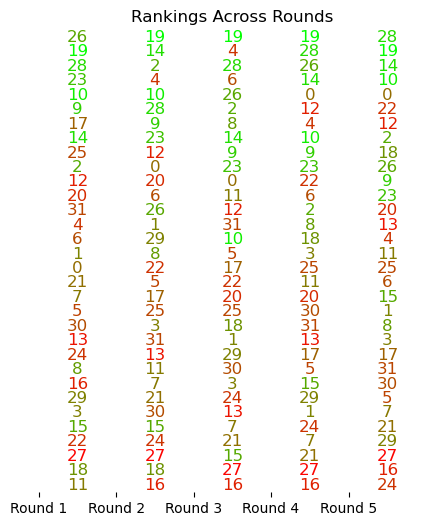

In [60]:
import matplotlib.pyplot as plt

def elo_to_color(elo):
    """Convert an Elo rating to a color in the gradient from red to green."""
    # Normalize Elo between 0 and 1
    norm_elo = (elo - MIN_ELO) / (MAX_ELO - MIN_ELO)
    # Ensure norm_elo is between 0 and 1
    norm_elo = np.clip(norm_elo, 0, 1)
    # Create a color from red (low Elo) to green (high Elo)
    return (1 - norm_elo, norm_elo, 0)  # RGB format

def plot_rankings(rankings):
    num_rounds = len(rankings)
    num_items = len(rankings[0])
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(num_rounds, 6))  # Adjust width for number of rounds
    
    # Plot rankings for each round
    for round_idx, round_rankings in enumerate(rankings):
        for rank_idx, player in enumerate(round_rankings):
            # Align the rank text based on the ranking position
            ax.text(round_idx + 0.5, rank_idx + 0.5, str(player.idx), 
                    ha='center', va='center', fontsize=12, color = elo_to_color(player.elo))

    # Formatting the plot
    ax.set_xlim(0, num_rounds)
    ax.set_ylim(0, num_items)
    ax.set_xticks(range(num_rounds))
    ax.set_xticklabels([f"Round {i + 1}" for i in range(num_rounds)], fontsize=10)
    ax.set_yticks(range(1, num_items + 1))
    ax.invert_yaxis()  # Invert y-axis to have rank 1 at the top
    ax.set_title(f"Rankings Across Rounds")
    
    # Remove unnecessary axes for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.yaxis.set_visible(False)
    
    plt.show()

plot_rankings(ranking_history)


The greener the stronger the player is. Each column represents the standings after the next round, and each plair is playing the other


In [61]:
ranking_history[-1][4]

Player 0: Elo=1554.8937480884501, Score=122.23172155604149
	, Track['player 1: 2', 'player 21: 3', 'player 12: 2', 'player 11: 3', 'player 12: 2']

Cool! Now, onto implementing the different scoring systems.

## Scoring systems
### Scoring strategy
What I choose to do is to first compute the winner score for each scenario, determine their point based on "how good" they performed. Then I compute the loser score. For a draw, I proceed similarly starting with the "highest" drawer.

The winner / best drawer score is given by his "normalised" score computed during the outcome, times the maximum score he can obtain (and shifted according to the minimum possible score), rounded up (down for the loser). 

### Northern Kings scoring system
This is by far the hardest system to implement since the scoring depends on the scenario... I ll just play the scenarios in the book order. For each scenario I ll mark the min / max points scored by the winner / loser / draw. acknowledging that the maximum number of scenario points is 5:
* Pillage  (1/7 0/3 0/3)
* Loot     (2/6 0/2 0/2)
* Push     (1/6 0/3 0/4)
* Dominate (1/7 0/6 0/5)
* Invade   (1/7 0/6 0/5)


* Win / Draw / loss basic scores: 15 / 10 / 5

* Then the KP are from 0 to 5


In [62]:
from math import ceil, floor

NK_scores= [
    [1,7,0,3,0,3],
    [2,6,0,2,0,2],
    [1,6,0,3,0,4],
    [1,7,0,6,0,5],
    [1,7,0,6,0,5],
    [1,7,0,6,0,5],
]

def result_sp_win(player_score,round_number):    
    return ceil(float(NK_scores[round_number][0] + (NK_scores[round_number][1] - NK_scores[round_number][0]) * player_score))

def result_sp_loss(player_score,round_number, winner_sp):
    return min(winner_sp-1,floor(float(NK_scores[round_number][4] + (NK_scores[round_number][5] - NK_scores[round_number][4]) * player_score)))

def result_draw_win(player_score,round_number):
    return ceil(float(NK_scores[round_number][2] + (NK_scores[round_number][3] - NK_scores[round_number][2]) * player_score))

def result_draw_loss(player_score,round_number, winner_sp):
    return winner_sp #necessary the same sp score


def final_score(res, sp_score, normalised_score):
    return res *5 + min(5,sp_score) + floor(float(normalised_score * 5)) 

def nk_score(result_triplet, round_number):
    res1 = result_triplet[0]
    res2 = rev(res1) 
    if(res1 == 3):
        normalised_score_win  = result_triplet[1]
        normalised_score_loss = result_triplet[2]
        sp_win   = result_sp_win (normalised_score_win, round_number)
        sp_loss  = result_sp_loss(normalised_score_loss,round_number, sp_win)
        return [final_score(res1, sp_win, normalised_score_win), final_score(res2, sp_loss, normalised_score_loss)] 
    if (res1 == 2):
        if(result_triplet[1]>result_triplet[2]):
            normalised_score_win  = result_triplet[1]
            normalised_score_loss = result_triplet[2]
            sp_win   = result_draw_win (normalised_score_win, round_number)
            sp_loss  = result_draw_loss(normalised_score_loss,round_number, sp_win)
            return [final_score(res1, sp_win, normalised_score_win), final_score(res2, sp_loss, normalised_score_loss)] 
        else:
            normalised_score_win  = result_triplet[2]
            normalised_score_loss = result_triplet[1]
            sp_win   = result_draw_win (normalised_score_win, round_number)
            sp_loss  = result_draw_loss(normalised_score_loss,round_number, sp_win)
            return [final_score(res1, sp_loss, normalised_score_loss), final_score(res2, sp_win, normalised_score_win)] 
    else:
        normalised_score_win  = result_triplet[2]
        normalised_score_loss = result_triplet[1]
        sp_win   = result_sp_win (normalised_score_win, round_number)
        sp_loss  = result_sp_loss(normalised_score_loss,round_number, sp_win)
        return [final_score(res1, sp_loss, normalised_score_loss), final_score(res2, sp_win, normalised_score_win)]
            
        

Let's see how the same tournament goes under the NK ruling system

In [63]:
final_rank, ranking_history_NK = play_tournament(data[0], data[1], nk_score)

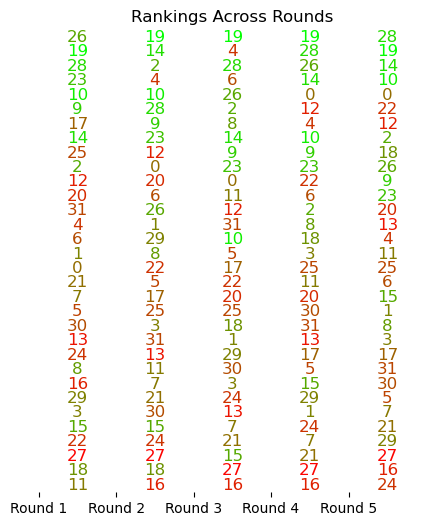

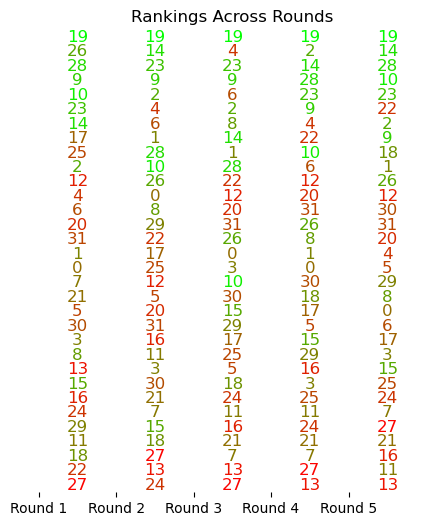

[Player 28: Elo=1814.9625481767707, Score=142.62555185519105
 	, Track['player 29: 3', 'player 23: 2', 'player 10: 3', 'player 6: 3', 'player 19: 3'],
 Player 19: Elo=1894.4768078327857, Score=133.3995051488501
 	, Track['player 18: 3', 'player 26: 3', 'player 14: 3', 'player 4: 3', 'player 28: 1'],
 Player 14: Elo=1823.9792849946573, Score=132.72218615131376
 	, Track['player 15: 3', 'player 17: 3', 'player 19: 1', 'player 8: 3', 'player 26: 3'],
 Player 10: Elo=1861.4812499826778, Score=123.6639376705788
 	, Track['player 11: 3', 'player 9: 2', 'player 28: 1', 'player 5: 3', 'player 4: 3'],
 Player 0: Elo=1554.8937480884501, Score=122.23172155604149
 	, Track['player 1: 2', 'player 21: 3', 'player 12: 2', 'player 11: 3', 'player 12: 2'],
 Player 22: Elo=1416.115721553984, Score=121.81100583916609
 	, Track['player 23: 1', 'player 27: 3', 'player 5: 2', 'player 17: 3', 'player 6: 3'],
 Player 12: Elo=1371.1371342510554, Score=121.29290902356625
 	, Track['player 13: 3', 'player 20: 2'

In [64]:
plot_rankings(ranking_history)
plot_rankings(ranking_history_NK)
ranking_history[-1][:]


### Black jack scoring system
In the black jack system you need to compare both scores to decide the performance of each player, both for scenario points and victory points. I ll compute the scenario points score of the winner as the difference between their normalised score and the normalised loser score times 4, rounded up (and at a minimum of 0). The loser then gets minus that score.
For the attrition, I ll just compute the difference between the normalised scores times 3, but this one can be negative. The loser gets minus the score (which can be positive).



In [65]:
import numpy as np


def result_sp_win_BJ(player1_score,player2_score):
    score1 = max(0, np.round((player1_score - player2_score) * 4))
    return score1, -score1


def result_sp_loss_BJ(player1_score,player2_score):
    score2, score1 = result_sp_win(player2_score, player1_score)
    return score1, score2


def result_sp_draw_BJ(player1_score,player2_score):
    return 0,0


def result_kp_BJ(player1_score,player2_score):
    score1 = np.round((player1_score- player2_score) * 3)
    return score1, -score1




def bj_score(result_triplet, round_number):
    res1 = result_triplet[0]
    res2 = rev(res1) 
    if(res1 == 3):
        normalised_score_win  = result_triplet[1]
        normalised_score_loss = result_triplet[2]
        score1_sp, score2_sp = result_sp_win_BJ(normalised_score_win,normalised_score_loss)
        score1_kp, score2_kp = result_kp_BJ    (normalised_score_win,normalised_score_loss)        
        return [14+score1_sp+score1_kp, 7+score2_sp+score2_kp] 
    if(res1==1):        
        normalised_score_win  = result_triplet[2]
        normalised_score_loss = result_triplet[1]
        score2_sp, score1_sp = result_sp_win_BJ(normalised_score_win,normalised_score_loss)
        score2_kp, score1_kp = result_kp_BJ    (normalised_score_win,normalised_score_loss)        
        return [14+score1_sp+score1_kp, 7+score2_sp+score2_kp] 
    else:
        score1_kp, score2_kp = result_kp_BJ(result_triplet[1],result_triplet[2])    
        return [10+score1_kp, 10+score2_kp] 

In [66]:
final_rank, ranking_history_BK = play_tournament(data[0], data[1], bj_score)

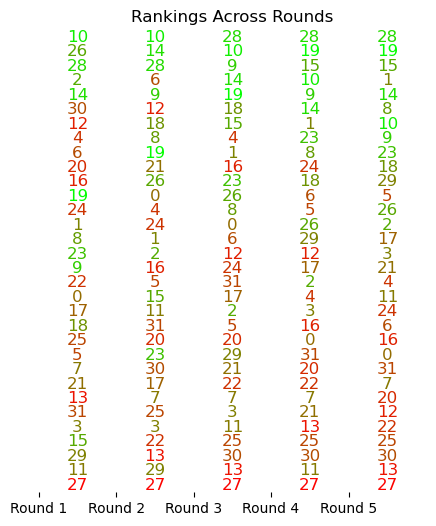

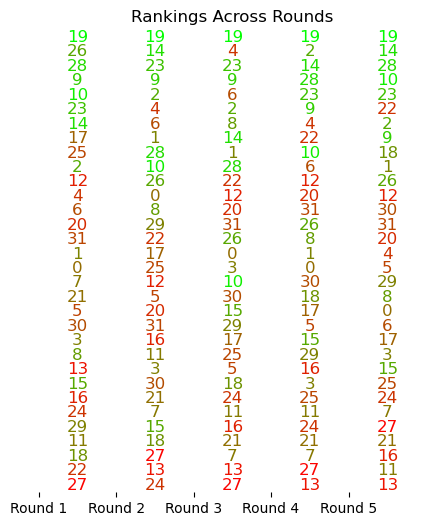

In [67]:
plot_rankings(ranking_history_BK)
plot_rankings(ranking_history_NK)


## III. System metrics
There are many metrics that we can consider in general, but they are all more of less subjective.
One which is objective though is that, if we run a very large number of tournaments, the best players should overall trust the top positions. Let's play 1000 tournaments and measure, for each system, on average the "distance" between each player and their estimated positions. We'll use the [Kendall Tau](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient) to measure the distance. All metrics are normalised to the **[0, 1]** range: a value of 0 means perfect agreement and 1 means maximum disagreement.


###  ELO Distance
How aligned is the ranking with respect to the theoretical level of the players? 
I am not convinced this metric is so interesting as it is very theoretical and in kings of war the army pairings are quite important as well. We'll write it anyway and see what to conclude from it


In [68]:

from scipy.stats import kendalltau



def elodistance(tournament_ranking, top_n=None):
    elos = [player.elo for player in tournament_ranking]
    sortedelos = sorted(elos, reverse=True)
    if top_n is not None:
        sortedelos = sortedelos[:top_n]
        elos = elos[:top_n]
    tau, p_value = kendalltau(sortedelos, elos)
    return (1 - tau) / 2


### Metric: Number of wins
Let's check that the winner is the one with the most wins / draws

In [69]:
def winner_has_win(tournament_ranking):
    wins = [num_win_draw(player) for player in tournament_ranking]
    sortedwins = sorted(wins, reverse=True)
    tau, p_value = kendalltau(wins, sortedwins)
    return (1 - tau) / 2


### Metric: The Bigger the Better

Among players with the same number of wins and draws, does the ranking reward those who won more dominantly? We group players by their win count and, within each group, check whether higher-ranked players also have a higher Elo (as a proxy for "bigger" wins — stronger players tend to produce larger margins). The cost is the fraction of discordant pairs within same-win groups: 0 means perfect agreement, 1 means fully inverted.

In [70]:
from collections import defaultdict

def bigger_the_better(tournament_ranking):
    win_groups = defaultdict(list)
    for rank_pos, player in enumerate(tournament_ranking):
        wins = num_win_draw(player)
        win_groups[wins].append((rank_pos, player))
    total_pairs = 0
    discordant = 0
    for wins, players in win_groups.items():
        if len(players) < 2:
            continue
        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                rank_i, player_i = players[i]
                rank_j, player_j = players[j]
                total_pairs += 1
                # rank_i < rank_j means player_i is ranked higher
                # player_i.elo > player_j.elo means player_i is stronger
                if (rank_i < rank_j) != (player_i.elo > player_j.elo):
                    discordant += 1
    return discordant / total_pairs if total_pairs > 0 else 0

### Metric: Submariners

Does the scoring system reward losing early? In Swiss-style systems, losing early means facing weaker opponents later, making it easier to accumulate wins. We build a reference ranking where players are sorted by wins (desc), then draws (desc), then a "late loss" score (sum of round indices where losses occurred — higher means losses came later). We then compute a Kendall tau between this reference and the actual tournament ranking. A cost of 0 means the system perfectly reflects the reference; 0.5 means random; higher values indicate the system rewards early losses.

In [71]:

def submariner_metric(tournament_ranking):
    # Build a reference ranking: wins desc, draws desc, late-loss score desc
    # Late-loss score = sum of round indices where player lost (higher = lost later = better)
    scores = []
    for player in tournament_ranking:
        wins = sum(1 for r in player.resulttrack if r == 3)
        draws = sum(1 for r in player.resulttrack if r == 2)
        loss_round_sum = sum(r for r, res in enumerate(player.resulttrack) if res == 1)
        score = wins * 10000 + draws * 100 + loss_round_sum
        scores.append(score)
    sorted_scores = sorted(scores, reverse=True)
    tau, _ = kendalltau(sorted_scores, scores)
    return (1 - tau) / 2

### Metric: Games Balance

Are players mostly playing opponents of similar strength? A good pairing system should match players with comparable Elo ratings as the tournament progresses. For each game played, we compute the absolute Elo difference between the two opponents, normalised by the maximum possible Elo gap in the tournament. The metric returns the average normalised Elo gap across all games. A cost of 0 means all games are perfectly balanced; 1 means every game is a maximum mismatch.

In [72]:
def games_balance(tournament_ranking):
    elo_map = {p.idx: p.elo for p in tournament_ranking}
    all_elos = list(elo_map.values())
    max_gap = max(all_elos) - min(all_elos)
    if max_gap == 0:
        return 0
    total_gap = 0
    total_games = 0
    for player in tournament_ranking:
        # Skip round 1 (index 0) since pairing is random
        for opp_idx in player.opponenttrack[1:]:
            total_gap += abs(player.elo - elo_map[opp_idx])
            total_games += 1
    # each game counted twice (once per player)
    return (total_gap / total_games) / max_gap if total_games > 0 else 0

### Metric: Replays

Do players face the same opponent multiple times during the tournament? In a 5-round, 32-player tournament there are enough players that ideally no one should play the same opponent twice. We count the total number of repeated pairings across all players (each repeat counted once), normalised by the total number of games. A cost of 0 means no replays at all; higher values indicate more repeat matchups.

In [73]:
def replays_metric(tournament_ranking):
    total_replays = 0
    total_games = 0
    for player in tournament_ranking:
        seen = set()
        for opp_idx in player.opponenttrack:
            total_games += 1
            if opp_idx in seen:
                total_replays += 1
            seen.add(opp_idx)
    # each game counted twice (once per player), same for replays
    return total_replays / total_games if total_games > 0 else 0

### Metric: Eat the Weak

Are strong players who happen to be paired against weaker opponents unfairly boosted in the final ranking? For each player we compute the average Elo of their opponents: a lower average means they faced weaker opposition. We then check, among players with the same win count, whether those who faced weaker opponents end up ranked higher. The cost is the fraction of discordant pairs where the player who faced weaker opponents is ranked above the one who faced stronger opponents. A value of 0 means no such advantage; higher values indicate the system rewards playing weak opponents.

In [74]:
def eat_the_weak(tournament_ranking):
    elo_map = {p.idx: p.elo for p in tournament_ranking}
    win_groups = defaultdict(list)
    for rank_pos, player in enumerate(tournament_ranking):
        wins = num_win_draw(player)
        avg_opp_elo = sum(elo_map[o] for o in player.opponenttrack) / len(player.opponenttrack) if player.opponenttrack else 0
        win_groups[wins].append((rank_pos, avg_opp_elo))
    total_pairs = 0
    weak_advantage = 0
    for wins, players in win_groups.items():
        if len(players) < 2:
            continue
        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                rank_i, avg_opp_i = players[i]
                rank_j, avg_opp_j = players[j]
                if avg_opp_i == avg_opp_j:
                    continue
                total_pairs += 1
                # rank_i < rank_j means i is ranked higher
                # avg_opp_i < avg_opp_j means i faced weaker opponents
                if (rank_i < rank_j) == (avg_opp_i < avg_opp_j):
                    weak_advantage += 1
    return weak_advantage / total_pairs if total_pairs > 0 else 0

### Metric: Strength of Schedule

Among players with the same win/draw record, does the ranking reward those who faced tougher opponents? For each player we compute a WDL-based Strength of Schedule: the sum of (wins×15 + draws×10) of all their opponents. Within each group of players sharing the same (wins, draws) count, we check whether higher-ranked players also have a higher SOS. The cost is the fraction of discordant pairs: 0 means the ranking perfectly rewards tougher schedules, 1 means it systematically rewards weaker schedules.

In [75]:
def sos_metric(tournament_ranking):
    players_by_idx = {p.idx: p for p in tournament_ranking}
    wd_groups = defaultdict(list)
    for rank_pos, player in enumerate(tournament_ranking):
        wins = num_win(player)
        draws = num_draw(player)
        sos = compute_sos(player, players_by_idx)
        wd_groups[(wins, draws)].append((rank_pos, sos))
    total_pairs = 0
    discordant = 0
    for wd, players in wd_groups.items():
        if len(players) < 2:
            continue
        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                rank_i, sos_i = players[i]
                rank_j, sos_j = players[j]
                if sos_i == sos_j:
                    continue
                total_pairs += 1
                if (rank_i < rank_j) != (sos_i > sos_j):
                    discordant += 1
    return discordant / total_pairs if total_pairs > 0 else 0


In [76]:
def winner_accuracy(tournament_ranking):
    """Returns 1 if the highest-ELO player is NOT ranked #1, else 0.
    Averaged over many tournaments this gives the failure rate."""
    best_elo = max(p.elo for p in tournament_ranking)
    return 0 if tournament_ranking[0].elo == best_elo else 1

def top_3_accuracy(tournament_ranking):
    """Cost = 1 - (overlap of true top-3 ELO with ranking top-3) / 3.
    0 = all three correct, 1 = none correct."""
    sorted_by_elo = sorted(tournament_ranking, key=lambda p: -p.elo)
    true_top3_idx = {p.idx for p in sorted_by_elo[:3]}
    ranked_top3_idx = {p.idx for p in tournament_ranking[:3]}
    overlap = len(true_top3_idx & ranked_top3_idx)
    return 1 - overlap / 3

In [77]:
# Generate 1000 tournaments (uses current N_PLAYERS / NUM_ROUNDS)
import os
os.makedirs("./tournaments_32", exist_ok=True)
for i in range(1000):
    name = "./tournaments_32/tournament_data" + str(i) + ".pkl"
    generate_data(reset_data=False, file_name=name)


In [78]:
# scoring_systems: [name, score_fn, pairing_mode, final_ranking_mode, format]
scoring_systems = [
    ["BJ",              bj_score,    "score",       None,         "swiss"],
    ["NK",              nk_score,    "score",       None,         "swiss"],
    ["W.flat+SOS",      naive_score, "wt_flat_sos", None,         "swiss"],
    ["NK|WDL+SOS",      nk_score,    "score",       "wdl_sos",    "swiss"],
    ["BJ|WDL+SOS",      bj_score,    "score",       "wdl_sos",    "swiss"],
    ["Pool+NK",         nk_score,    "score",       None,         "pool"],
    ["Pool+NK|WDL+SOS", nk_score,    "score",       "wdl_sos",    "pool"],
    ["Pool+BJ",         bj_score,    "score",       None,         "pool"],
    ["Pool+W.flat+SOS", naive_score, "wt_flat_sos", None,         "pool"],
]
metrics = [
    ["elo distance",         elodistance],
    ["elo distance top 10",  lambda r: elodistance(r, top_n=10)],
    ["wins",                 winner_has_win],
    ["bigger the better",    bigger_the_better],
    ["submariners",          submariner_metric],
    ["games balance",        games_balance],
    ["eat the weak",         eat_the_weak],
    ["strength of schedule", sos_metric],
    ["winner accuracy",      winner_accuracy],
    ["top 3 accuracy",       top_3_accuracy],
]


In [79]:
#load tournaments and run
tournaments = [generate_data(reset_data=False, file_name="./tournaments_32/tournament_data"+str(i)+".pkl") for i in range(1000)]

In [80]:
def run_analysis(tournament_data_list):
    """Run all scoring systems on all tournaments sequentially and aggregate results."""
    analysis = {}
    n = len(tournament_data_list)
    for t_idx, data in enumerate(tournament_data_list):
        if t_idx % 100 == 0:
            print(f"  {t_idx}/{n}...", end="\r")
        for ss_entry in scoring_systems:
            ss_name, ss, mode, final_mode, fmt = ss_entry
            if fmt == "pool":
                final_rank, _ = play_pool_tournament(
                    data[0], data[1], ss, ranking_mode=mode, final_ranking_mode=final_mode)
            else:
                final_rank, _ = play_tournament(
                    data[0], data[1], ss, ranking_mode=mode, final_ranking_mode=final_mode,
                    collect_history=False)
            for metric_name, metric_fn in metrics:
                if metric_name not in analysis:
                    analysis[metric_name] = {}
                if ss_name not in analysis[metric_name]:
                    analysis[metric_name][ss_name] = []
                analysis[metric_name][ss_name].append(metric_fn(final_rank))
    # Aggregate
    for metric_name, _ in metrics:
        for ss_entry in scoring_systems:
            ss_name = ss_entry[0]
            raw = analysis[metric_name][ss_name]
            analysis[metric_name][ss_name] = {
                'average cost': sum(raw) / len(raw),
                'worst': max(raw),
                'standard deviation': float(np.std(raw, ddof=1)),
            }
    print(f"Done! ({n} tournaments)")
    return analysis

res = run_analysis(tournaments)


Done! (1000 tournaments)


In [81]:
import pandas as pd

def display_results(res):
    rows = []
    for metric_name, systems in res.items():
        for sys_name, stats in systems.items():
            rows.append({
                'Criterion': metric_name,
                'System': sys_name,
                'Avg Cost': stats['average cost'],
            })
    df = pd.DataFrame(rows)
    df = df.pivot_table(index='Criterion', columns='System', values='Avg Cost', aggfunc='first')
    vmax = df.values.max()
    def gradient(row):
        styles = []
        for v in row.values:
            t = max(0.0, min(1.0, v / vmax)) if vmax > 0 else 0
            r = int(34 + t * (204 - 34))
            g = int(170 - t * (170 - 51))
            b = int(34 + t * (51 - 34))
            styles.append(f'background-color: rgb({r},{g},{b}); color: white; font-weight: bold')
        return styles
    return (df.style
              .apply(gradient, axis=1)
              .format('{:.2f}')
              .set_properties(**{'font-size': '14px'}))


In [82]:
display_results(res)


System,BJ,BJ|WDL+SOS,NK,NK|WDL+SOS,Pool+BJ,Pool+NK,Pool+NK|WDL+SOS,Pool+W.flat+SOS,W.flat+SOS
Criterion,,,,,,,,,
bigger the better,0.25,0.34,0.16,0.34,0.28,0.17,0.35,0.42,0.41
eat the weak,0.32,0.28,0.40,0.32,0.40,0.51,0.40,0.36,0.28
elo distance,0.21,0.29,0.21,0.28,0.22,0.20,0.26,0.26,0.27
elo distance top 10,0.34,0.38,0.35,0.37,0.35,0.34,0.37,0.36,0.37
games balance,0.26,0.26,0.24,0.24,0.30,0.28,0.28,0.29,0.26
strength of schedule,0.35,0.00,0.37,0.00,0.35,0.38,0.00,0.00,0.00
submariners,0.33,0.03,0.12,0.02,0.30,0.10,0.03,0.02,0.02
top 3 accuracy,0.52,0.66,0.54,0.66,0.57,0.51,0.60,0.60,0.63
winner accuracy,0.76,0.82,0.74,0.82,0.80,0.74,0.79,0.79,0.80


## IV. Results

The table above summarises how each scoring system performs across all evaluation criteria, averaged over 1000 simulated tournaments. Lower values are better: a cost of 0 means the ranking perfectly matches the ideal ordering for that criterion.

We compare NK and BJ (raw score pairing), SOS-enhanced variants (WDL+SOS final ranking), and pool-phase variants (3 rounds of pool play followed by 2 Swiss rounds).


In [83]:
# Compact text summary
for metric_name, systems in res.items():
    line = f"{metric_name:25s} |"
    for sys_name, stats in systems.items():
        line += f" {sys_name}={stats['average cost']:.3f} |"
    print(line)


elo distance              | BJ=0.209 | NK=0.208 | W.flat+SOS=0.267 | NK|WDL+SOS=0.281 | BJ|WDL+SOS=0.295 | Pool+NK=0.197 | Pool+NK|WDL+SOS=0.257 | Pool+BJ=0.223 | Pool+W.flat+SOS=0.256 |
elo distance top 10       | BJ=0.336 | NK=0.345 | W.flat+SOS=0.366 | NK|WDL+SOS=0.370 | BJ|WDL+SOS=0.383 | Pool+NK=0.337 | Pool+NK|WDL+SOS=0.368 | Pool+BJ=0.351 | Pool+W.flat+SOS=0.358 |
wins                      | BJ=0.321 | NK=0.098 | W.flat+SOS=0.000 | NK|WDL+SOS=0.000 | BJ|WDL+SOS=0.000 | Pool+NK=0.076 | Pool+NK|WDL+SOS=0.000 | Pool+BJ=0.296 | Pool+W.flat+SOS=0.000 |
bigger the better         | BJ=0.252 | NK=0.156 | W.flat+SOS=0.406 | NK|WDL+SOS=0.337 | BJ|WDL+SOS=0.335 | Pool+NK=0.171 | Pool+NK|WDL+SOS=0.354 | Pool+BJ=0.279 | Pool+W.flat+SOS=0.419 |
submariners               | BJ=0.325 | NK=0.122 | W.flat+SOS=0.017 | NK|WDL+SOS=0.022 | BJ|WDL+SOS=0.030 | Pool+NK=0.096 | Pool+NK|WDL+SOS=0.026 | Pool+BJ=0.302 | Pool+W.flat+SOS=0.023 |
games balance             | BJ=0.256 | NK=0.236 | W.flat+SOS=0.26

## V. Conclusion — 32 Players, 5 Rounds

No single scoring system dominates on every criterion. There is a clear **accuracy vs fairness trade-off**:

- **Accuracy-oriented systems** (BJ, NK, Pool+NK, Pool+BJ): best at elo distance, winner accuracy, and top-3 accuracy, but bad at wins, submariners, and strength of schedule.
- **Fairness-oriented systems** (W.flat+SOS, NK|WDL+SOS, BJ|WDL+SOS, Pool+NK|WDL+SOS, Pool+W.flat+SOS): perfect on wins, submariners, and SOS, but worse at ranking accuracy.

### Recommendations

- **Best overall ranking accuracy**: **Pool+NK** — best elo distance, best top-3 accuracy, second-best winner accuracy. The pool phase gives every player 3 meaningful games before Swiss pairing, improving differentiation.
- **Best fairness guarantees**: **W.flat+SOS** or **NK|WDL+SOS** — both achieve perfect wins (0.000), near-zero submariners, and perfect SOS (0.000). NK|WDL+SOS has the edge on games balance; W.flat+SOS is better at eat-the-weak.
- **Best all-round compromise**: **NK|WDL+SOS** — good games balance, perfect wins/SOS/submariners, reasonable elo distance. Trade-off: worst tier on winner and top-3 accuracy.
- **Best pool compromise**: **Pool+NK|WDL+SOS** — combines pool advantages with fairness guarantees.
- **Avoid BJ if wins matter**: BJ and Pool+BJ are the worst at ensuring more-wins-ranks-higher.

**The main conclusion is that if you want wins to primarily determine the tournament ranking, Black Jack is not the system you are after.**


## Appendix — 20 Players, 5 Rounds

With only 20 players and 5 rounds, the Swiss format is pushed to its limits: each player faces 5 out of 19 possible opponents (26%), leading to frequent rematches and less room for differentiation. We expect scoring systems to struggle more with accuracy and fairness.


In [84]:
# ── 20-player appendix (run after main results) ──────────────────────────────
N_PLAYERS_20 = 20
NUM_ROUNDS_20 = 5

# Temporarily override globals for data generation
_N_PLAYERS_orig, _NUM_ROUNDS_orig = N_PLAYERS, NUM_ROUNDS
N_PLAYERS = N_PLAYERS_20
NUM_ROUNDS = NUM_ROUNDS_20

import os
os.makedirs("./tournaments_20", exist_ok=True)
for i in range(1000):
    name = "./tournaments_20/tournament_data" + str(i) + ".pkl"
    generate_data(reset_data=False, file_name=name)
print(f"Generated 1000 tournaments with {N_PLAYERS} players, {NUM_ROUNDS} rounds.")


Generated 1000 tournaments with 20 players, 5 rounds.


In [85]:
tournaments_20 = [
    generate_data(reset_data=False,
                  file_name="./tournaments_20/tournament_data" + str(i) + ".pkl")
    for i in range(1000)
]
res_20 = run_analysis(tournaments_20)


Done! (1000 tournaments)


In [86]:
display_results(res_20)


System,BJ,BJ|WDL+SOS,NK,NK|WDL+SOS,Pool+BJ,Pool+NK,Pool+NK|WDL+SOS,Pool+W.flat+SOS,W.flat+SOS
Criterion,,,,,,,,,
bigger the better,0.25,0.33,0.15,0.31,0.28,0.16,0.33,0.40,0.38
eat the weak,0.33,0.27,0.42,0.32,0.41,0.51,0.41,0.35,0.27
elo distance,0.21,0.29,0.21,0.28,0.22,0.20,0.26,0.26,0.26
elo distance top 10,0.29,0.36,0.28,0.35,0.31,0.28,0.33,0.34,0.34
games balance,0.27,0.27,0.25,0.25,0.31,0.29,0.29,0.31,0.28
strength of schedule,0.35,0.00,0.34,0.00,0.36,0.36,0.00,0.00,0.00
submariners,0.32,0.03,0.13,0.02,0.30,0.10,0.03,0.02,0.02
top 3 accuracy,0.42,0.56,0.45,0.56,0.47,0.42,0.51,0.51,0.53
winner accuracy,0.67,0.74,0.64,0.73,0.73,0.61,0.70,0.69,0.71


In [87]:
for metric_name, systems in res_20.items():
    line = f"{metric_name:25s} |"
    for sys_name, stats in systems.items():
        line += f" {sys_name}={stats['average cost']:.3f} |"
    print(line)


elo distance              | BJ=0.206 | NK=0.207 | W.flat+SOS=0.264 | NK|WDL+SOS=0.282 | BJ|WDL+SOS=0.291 | Pool+NK=0.197 | Pool+NK|WDL+SOS=0.257 | Pool+BJ=0.223 | Pool+W.flat+SOS=0.255 |
elo distance top 10       | BJ=0.288 | NK=0.281 | W.flat+SOS=0.337 | NK|WDL+SOS=0.352 | BJ|WDL+SOS=0.362 | Pool+NK=0.279 | Pool+NK|WDL+SOS=0.329 | Pool+BJ=0.308 | Pool+W.flat+SOS=0.335 |
wins                      | BJ=0.318 | NK=0.104 | W.flat+SOS=0.000 | NK|WDL+SOS=0.000 | BJ|WDL+SOS=0.000 | Pool+NK=0.078 | Pool+NK|WDL+SOS=0.000 | Pool+BJ=0.301 | Pool+W.flat+SOS=0.000 |
bigger the better         | BJ=0.247 | NK=0.151 | W.flat+SOS=0.381 | NK|WDL+SOS=0.309 | BJ|WDL+SOS=0.334 | Pool+NK=0.155 | Pool+NK|WDL+SOS=0.332 | Pool+BJ=0.280 | Pool+W.flat+SOS=0.405 |
submariners               | BJ=0.322 | NK=0.128 | W.flat+SOS=0.016 | NK|WDL+SOS=0.022 | BJ|WDL+SOS=0.029 | Pool+NK=0.096 | Pool+NK|WDL+SOS=0.026 | Pool+BJ=0.304 | Pool+W.flat+SOS=0.023 |
games balance             | BJ=0.271 | NK=0.251 | W.flat+SOS=0.27

In [88]:
# Restore globals to 32-player configuration
N_PLAYERS = _N_PLAYERS_orig
NUM_ROUNDS = _NUM_ROUNDS_orig


### Conclusion — 20 Players, 5 Rounds

With only 20 players and 5 rounds, each player faces 5/19 = 26% of the field (vs 16% at 32p), leading to more pairing redundancy but also better top-player identification.

The per-metric ratings are remarkably consistent with the 32-player results — the same systems land in the same good/average/bad categories. With 20 players:

- **Winner accuracy improves**: fewer players make it easier to identify the true champion.
- **Top-3 accuracy also improves** for the same reason.
- **Games balance degrades slightly**: fewer players means less room for balanced pairings.
- **The accuracy vs fairness trade-off is identical** to the 32-player case.

**Pool+NK** remains the best for raw accuracy, **NK|WDL+SOS** for fairness guarantees, and **Pool+NK|WDL+SOS** for the best pool compromise.
